
Training with Batch Size: 32 Epochs: 10
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8108 - loss: 0.7360
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9127 - loss: 0.3114
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9206 - loss: 0.2874
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9247 - loss: 0.2691
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9264 - loss: 0.2631
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9290 - loss: 0.2541
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9294 - loss: 0.2560
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9311 - loss: 0.2501
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9310 - loss: 0.2500
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9314 - loss: 0.2517

Training with Batch Size: 32 Epochs: 15
Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━

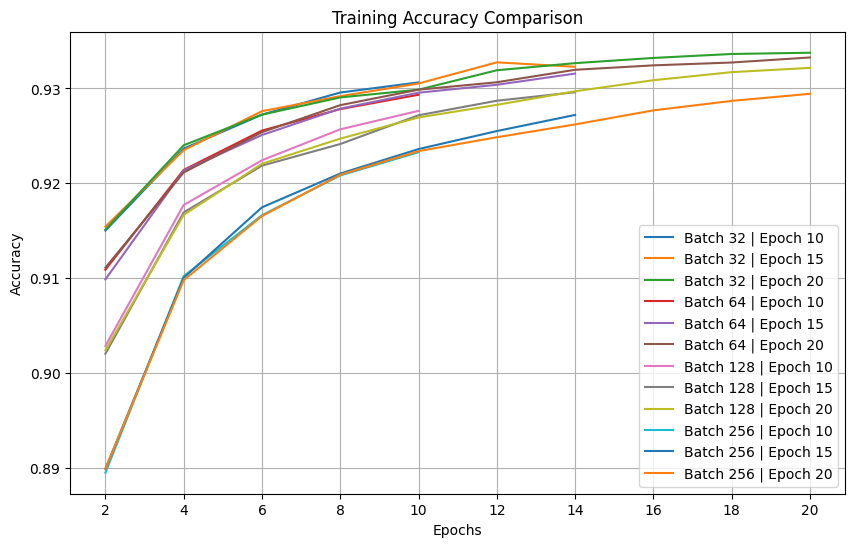

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Added batch size 256
batch_sizes = [32, 64, 128, 256]

epochs_list = [10, 15, 20]

epoch_points = list(range(2, 21, 2))

plt.figure(figsize=(10,6))

for batch in batch_sizes:
    for ep in epochs_list:

        print("\nTraining with Batch Size:", batch, "Epochs:", ep)

        model = Sequential([
            Dense(10, activation='softmax', input_shape=(784,))
        ])

        model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        # Train model
        history = model.fit(X_train, y_train, epochs=ep, batch_size=batch, verbose=1)

        acc_values = []
        for i in epoch_points:
            if i <= ep:
                acc_values.append(history.history['accuracy'][i-1])
            else:
                acc_values.append(None)

        plt.plot(epoch_points, acc_values, label=f'Batch {batch} | Epoch {ep}')

# Graph settings
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epoch_points)
plt.legend()
plt.grid(True)

plt.show()